# 07 — Modelado per-municipio (Paso 5)

**Proyecto:** Detección de excesos epidemiológicos de dengue en Colombia
**Maestría en IA — Desarrollo de Soluciones**

Entrena 2 modelos (Regresión Logística regularizada + XGBoost) por cada uno
de los 3 municipios foco, con split cronológico **train 2007–2019 / test
2020–2024**, y reporta Precision/Recall sobre el test.

**Decisiones aplicadas:**
- D3: partición cronológica (train ≤ 2019, test ≥ 2020).
- D4: métricas principales = Precision y Recall.
- D5: Logística regularizada + XGBoost. RF descartado, no deep learning.
- D15: 28 features (clima + lags casos/incidencia + estacionalidad cíclica).
- D16: defaults para Logística; GridSearchCV + TimeSeriesSplit(5) para XGBoost.
- D17: baseline trivial "casos_lag1 > 2" como piso comparativo.

**Salidas:**
- `models/{cod_mpio}_{modelo}.joblib` — modelos por municipio.
- `data/processed/predicciones_test.csv` — predicciones para el test.
- `results_graphs/foco/07_*.png` — matrices de confusión, comparativo de métricas, feature importance.


In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, roc_auc_score,
)
import xgboost as xgb
import joblib

sys.path.insert(0, os.path.join("..", "src"))
from utils import MUNICIPIOS_FOCO, PROJECT_ROOT, configurar_estilo

configurar_estilo()
pd.set_option("display.max_columns", 50)

PANEL = pd.read_parquet(PROJECT_ROOT / "data/processed/panel_municipal_mensual.parquet")
print(f"Panel: {PANEL.shape[0]} filas × {PANEL.shape[1]} columnas")

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
OUT_GRAPH = PROJECT_ROOT / "results_graphs" / "foco"
OUT_GRAPH.mkdir(parents=True, exist_ok=True)
OUT_PRED = PROJECT_ROOT / "data" / "processed" / "predicciones_test.csv"

COLOR = {"23855": "#1f77b4", "47288": "#d62728", "95025": "#2ca02c"}
ANO_TEST_DESDE = 2020   # train: ano <= 2019 ; test: ano >= 2020 (D3)


Panel: 648 filas × 42 columnas


## 1. Preparación del feature matrix

Agregamos estacionalidad cíclica (`mes_sin`, `mes_cos`), filtramos filas con
target indefinido (primeros años sin historia para el percentil) y dividimos
en train/test por año.


In [2]:
panel = PANEL.copy()
panel["mes_sin"] = np.sin(2 * np.pi * panel["mes"] / 12)
panel["mes_cos"] = np.cos(2 * np.pi * panel["mes"] / 12)

FEATURES_CLIMA = ["temperatura_c", "precipitacion_mm", "ndvi", "dewpoint_c"]
FEATURES_CLIMA_LAG = [f"{v}_lag{L}" for v in FEATURES_CLIMA for L in [1, 2, 3]]
FEATURES_CLIMA_MM3 = [f"{v}_mm3" for v in FEATURES_CLIMA]
FEATURES_CASOS_LAG = [f"casos_total_lag{L}" for L in [1, 2, 3]]
FEATURES_INC_LAG   = [f"incidencia_x100k_lag{L}" for L in [1, 2, 3]]
FEATURES_TIEMPO    = ["mes_sin", "mes_cos"]

FEATURES = (FEATURES_CLIMA + FEATURES_CLIMA_LAG + FEATURES_CLIMA_MM3
            + FEATURES_CASOS_LAG + FEATURES_INC_LAG + FEATURES_TIEMPO)
print(f"Total features: {len(FEATURES)}")
print(FEATURES)


Total features: 28
['temperatura_c', 'precipitacion_mm', 'ndvi', 'dewpoint_c', 'temperatura_c_lag1', 'temperatura_c_lag2', 'temperatura_c_lag3', 'precipitacion_mm_lag1', 'precipitacion_mm_lag2', 'precipitacion_mm_lag3', 'ndvi_lag1', 'ndvi_lag2', 'ndvi_lag3', 'dewpoint_c_lag1', 'dewpoint_c_lag2', 'dewpoint_c_lag3', 'temperatura_c_mm3', 'precipitacion_mm_mm3', 'ndvi_mm3', 'dewpoint_c_mm3', 'casos_total_lag1', 'casos_total_lag2', 'casos_total_lag3', 'incidencia_x100k_lag1', 'incidencia_x100k_lag2', 'incidencia_x100k_lag3', 'mes_sin', 'mes_cos']


In [3]:
# Filtrar filas con target definido y sin NaN en features
def preparar_subset(cod_mpio):
    sub = panel[panel["cod_mpio"] == cod_mpio].copy()
    sub = sub.dropna(subset=["exceso"] + FEATURES)
    sub = sub.sort_values(["ano", "mes"]).reset_index(drop=True)
    train = sub[sub["ano"] < ANO_TEST_DESDE].copy()
    test  = sub[sub["ano"] >= ANO_TEST_DESDE].copy()
    return sub, train, test

resumen_split = []
for cod, nom in MUNICIPIOS_FOCO.items():
    _, tr, te = preparar_subset(cod)
    resumen_split.append({
        "municipio": nom,
        "n_train": len(tr), "prevalencia_train_%": tr["exceso"].mean() * 100,
        "n_test": len(te),  "prevalencia_test_%":  te["exceso"].mean() * 100,
    })
pd.DataFrame(resumen_split).round(1)


,municipio,n_train,prevalencia_train_%,n_test,prevalencia_test_%
0,Valencia,132,27.3,60,66.7
1,Fundación,132,30.3,60,56.7
2,El Retorno,132,36.4,60,23.3


## 2. Baseline trivial: `casos_total_lag1 > 2`

Modelo más simple posible — sólo mira el mes pasado. Es el piso que cualquier
modelo entrenado debe superar para justificar su existencia.


In [4]:
def evaluar(y_true, y_pred, y_score=None):
    out = {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "accuracy":  accuracy_score(y_true, y_pred),
    }
    if y_score is not None and len(np.unique(y_true)) > 1:
        out["roc_auc"] = roc_auc_score(y_true, y_score)
    return out

resultados = []
for cod, nom in tqdm(MUNICIPIOS_FOCO.items(), desc="Baseline"):
    _, _, te = preparar_subset(cod)
    y_true = te["exceso"].astype(int).values
    y_pred_base = (te["casos_total_lag1"] > 2).astype(int).values
    m = evaluar(y_true, y_pred_base)
    m.update({"municipio": nom, "modelo": "Baseline (lag1>2)"})
    resultados.append(m)

pd.DataFrame(resultados).round(3)


Baseline:   0%|          | 0/3 [00:00<?, ?it/s]

,precision,recall,f1,accuracy,municipio,modelo
0,0.826,0.950,0.884,0.833,Valencia,Baseline (lag1>2)
1,0.674,0.912,0.775,0.700,Fundación,Baseline (lag1>2)
2,0.550,0.786,0.647,0.800,El Retorno,Baseline (lag1>2)


## 3. Regresión Logística regularizada (defaults + `class_weight=balanced`)

Un modelo por municipio. StandardScaler ajustado solo en train.


In [5]:
def entrenar_logistica(train, test):
    X_tr = train[FEATURES].values
    y_tr = train["exceso"].astype(int).values
    X_te = test[FEATURES].values
    y_te = test["exceso"].astype(int).values

    scaler = StandardScaler().fit(X_tr)
    Xs_tr = scaler.transform(X_tr)
    Xs_te = scaler.transform(X_te)

    modelo = LogisticRegression(class_weight="balanced", max_iter=2000,
                                random_state=42)
    modelo.fit(Xs_tr, y_tr)
    y_pred = modelo.predict(Xs_te)
    y_proba = modelo.predict_proba(Xs_te)[:, 1]
    return modelo, scaler, y_te, y_pred, y_proba

modelos_log = {}
for cod, nom in tqdm(MUNICIPIOS_FOCO.items(), desc="Logística"):
    _, tr, te = preparar_subset(cod)
    modelo, scaler, y_te, y_pred, y_proba = entrenar_logistica(tr, te)
    modelos_log[cod] = {"model": modelo, "scaler": scaler,
                        "features": FEATURES,
                        "y_test": y_te, "y_pred": y_pred, "y_proba": y_proba}
    m = evaluar(y_te, y_pred, y_proba)
    m.update({"municipio": nom, "modelo": "Logística"})
    resultados.append(m)

pd.DataFrame([r for r in resultados if r["modelo"] == "Logística"]).round(3)


Logística:   0%|          | 0/3 [00:00<?, ?it/s]

,precision,recall,f1,accuracy,roc_auc,municipio,modelo
0,0.822,0.925,0.871,0.817,0.866,Valencia,Logística
1,0.733,0.647,0.688,0.667,0.742,Fundación,Logística
2,0.333,0.500,0.400,0.650,0.621,El Retorno,Logística


## 4. XGBoost con `GridSearchCV` + `TimeSeriesSplit(5)`

Grid pequeño (8 combinaciones) × 5 folds × 3 municipios = 120 ajustes.
Métrica de selección: F1.


In [6]:
PARAM_GRID = {
    "n_estimators":  [100, 300],
    "max_depth":     [3, 5],
    "learning_rate": [0.05, 0.1],
}

def entrenar_xgboost(train, test):
    X_tr = train[FEATURES].values
    y_tr = train["exceso"].astype(int).values
    X_te = test[FEATURES].values
    y_te = test["exceso"].astype(int).values

    scaler = StandardScaler().fit(X_tr)  # opcional para XGB; uniformiza el pipeline
    Xs_tr = scaler.transform(X_tr)
    Xs_te = scaler.transform(X_te)

    pos = int(y_tr.sum()); neg = int(len(y_tr) - pos)
    spw = neg / max(pos, 1)
    base = xgb.XGBClassifier(
        objective="binary:logistic",
        scale_pos_weight=spw,
        eval_metric="logloss",
        random_state=42,
        n_jobs=1,
        verbosity=0,
    )

    tscv = TimeSeriesSplit(n_splits=5)
    gs = GridSearchCV(base, PARAM_GRID, cv=tscv, scoring="f1",
                      n_jobs=-1, verbose=0)
    gs.fit(Xs_tr, y_tr)
    y_pred = gs.best_estimator_.predict(Xs_te)
    y_proba = gs.best_estimator_.predict_proba(Xs_te)[:, 1]
    return gs.best_estimator_, scaler, gs.best_params_, y_te, y_pred, y_proba

modelos_xgb = {}
for cod, nom in tqdm(MUNICIPIOS_FOCO.items(), desc="XGBoost (GridSearch)"):
    _, tr, te = preparar_subset(cod)
    modelo, scaler, params, y_te, y_pred, y_proba = entrenar_xgboost(tr, te)
    modelos_xgb[cod] = {"model": modelo, "scaler": scaler,
                        "features": FEATURES, "best_params": params,
                        "y_test": y_te, "y_pred": y_pred, "y_proba": y_proba}
    m = evaluar(y_te, y_pred, y_proba)
    m.update({"municipio": nom, "modelo": "XGBoost", "best_params": str(params)})
    resultados.append(m)

pd.DataFrame([r for r in resultados if r["modelo"] == "XGBoost"]).round(3)


XGBoost (GridSearch):   0%|          | 0/3 [00:00<?, ?it/s]

,precision,recall,f1,accuracy,roc_auc,municipio,modelo,best_params
0,0.841,0.925,0.881,0.833,0.790,Valencia,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
1,0.806,0.853,0.829,0.800,0.782,Fundación,XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
2,0.500,0.571,0.533,0.767,0.797,El Retorno,XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."


## 5. Comparativo consolidado de métricas

Las dos métricas decisorias son **Precision** y **Recall** sobre el test. El
comparador externo: el modelo nacional de Entrega 1 obtuvo P=43% / R=87%.


In [7]:
df_res = pd.DataFrame(resultados).round(3)
tabla = (df_res
         .pivot_table(index="municipio", columns="modelo",
                      values=["precision", "recall", "f1"])
         .round(3))
tabla


f1                           precision            \
modelo     Baseline (lag1>2) Logística XGBoost Baseline (lag1>2) Logística   
municipio                                                                    
El Retorno             0.647     0.400   0.533             0.550     0.333   
Fundación              0.775     0.688   0.829             0.674     0.733   
Valencia               0.884     0.871   0.881             0.826     0.822   

                              recall                    
modelo     XGBoost Baseline (lag1>2) Logística XGBoost  
municipio                                               
El Retorno   0.500             0.786     0.500   0.571  
Fundación    0.806             0.912     0.647   0.853  
Valencia     0.841             0.950     0.925   0.925

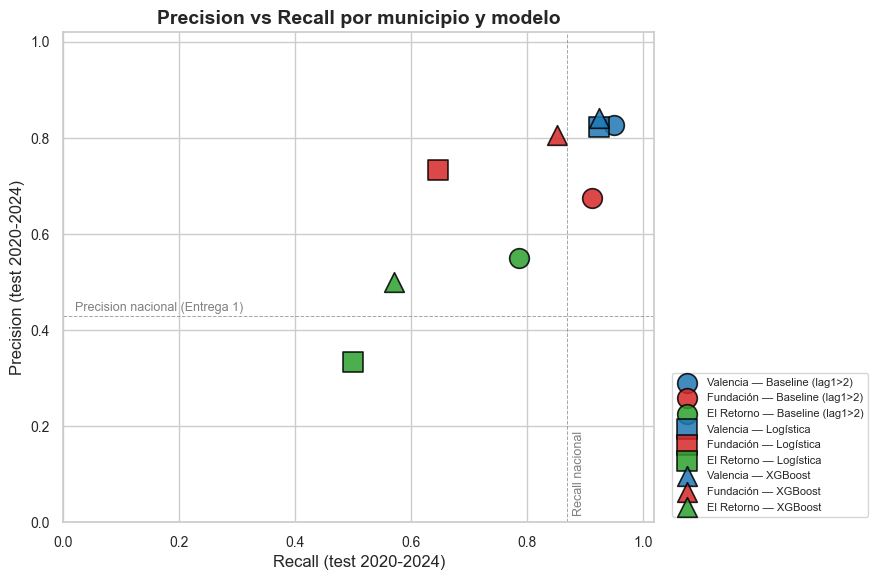

In [8]:
# Gráfico comparativo Precision vs Recall por municipio y modelo
fig, ax = plt.subplots(figsize=(9, 6))
marcadores = {"Baseline (lag1>2)": "o", "Logística": "s", "XGBoost": "^"}
for _, r in df_res.iterrows():
    ax.scatter(r["recall"], r["precision"],
               s=200, color=COLOR[[c for c, n in MUNICIPIOS_FOCO.items()
                                    if n == r["municipio"]][0]],
               marker=marcadores[r["modelo"]],
               edgecolor="black", linewidth=1.2,
               label=f"{r['municipio']} — {r['modelo']}", alpha=0.85)
ax.axhline(0.43, color="gray", lw=0.7, linestyle="--", alpha=0.7)
ax.text(0.02, 0.44, "Precision nacional (Entrega 1)", color="gray", fontsize=9)
ax.axvline(0.87, color="gray", lw=0.7, linestyle="--", alpha=0.7)
ax.text(0.88, 0.02, "Recall nacional", color="gray", fontsize=9, rotation=90)
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
ax.set_xlabel("Recall (test 2020-2024)")
ax.set_ylabel("Precision (test 2020-2024)")
ax.set_title("Precision vs Recall por municipio y modelo", fontweight="bold")
ax.legend(fontsize=8, loc="lower left", bbox_to_anchor=(1.02, 0))
plt.tight_layout()
plt.savefig(OUT_GRAPH / "07_precision_recall.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Matrices de confusión


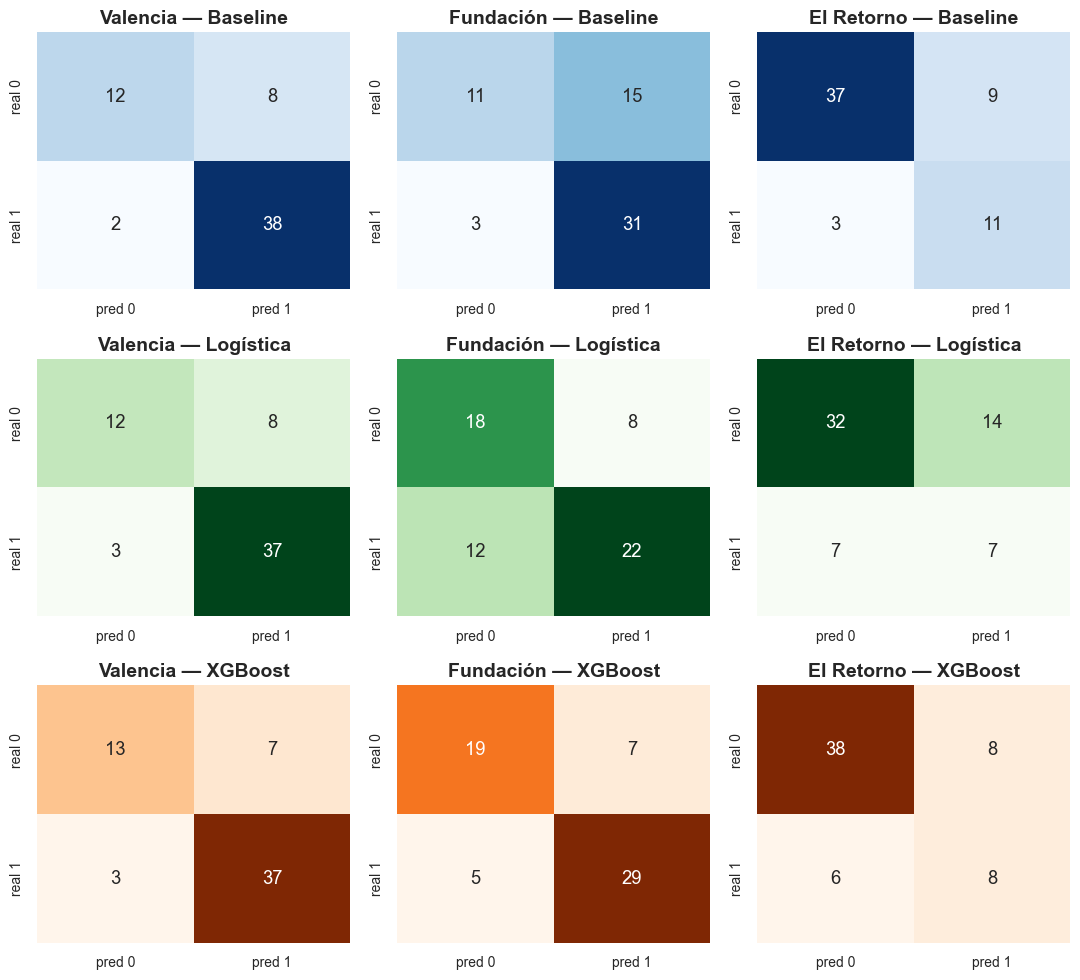

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(11, 10))
modelos_dict = {"Baseline": None, "Logística": modelos_log, "XGBoost": modelos_xgb}

for col_idx, (cod, nom) in enumerate(MUNICIPIOS_FOCO.items()):
    _, _, te = preparar_subset(cod)
    y_true = te["exceso"].astype(int).values
    # Baseline
    y_pred_b = (te["casos_total_lag1"] > 2).astype(int).values
    cm = confusion_matrix(y_true, y_pred_b)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                ax=axes[0, col_idx], cbar=False,
                xticklabels=["pred 0", "pred 1"],
                yticklabels=["real 0", "real 1"])
    axes[0, col_idx].set_title(f"{nom} — Baseline", fontweight="bold")
    # Logística
    y_pred = modelos_log[cod]["y_pred"]
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                ax=axes[1, col_idx], cbar=False,
                xticklabels=["pred 0", "pred 1"],
                yticklabels=["real 0", "real 1"])
    axes[1, col_idx].set_title(f"{nom} — Logística", fontweight="bold")
    # XGBoost
    y_pred = modelos_xgb[cod]["y_pred"]
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
                ax=axes[2, col_idx], cbar=False,
                xticklabels=["pred 0", "pred 1"],
                yticklabels=["real 0", "real 1"])
    axes[2, col_idx].set_title(f"{nom} — XGBoost", fontweight="bold")

plt.tight_layout()
plt.savefig(OUT_GRAPH / "07_matrices_confusion.png", dpi=120,
            bbox_inches="tight")
plt.show()


## 7. Feature importance — XGBoost por municipio

¿Qué variables están moviendo las predicciones en cada uno?


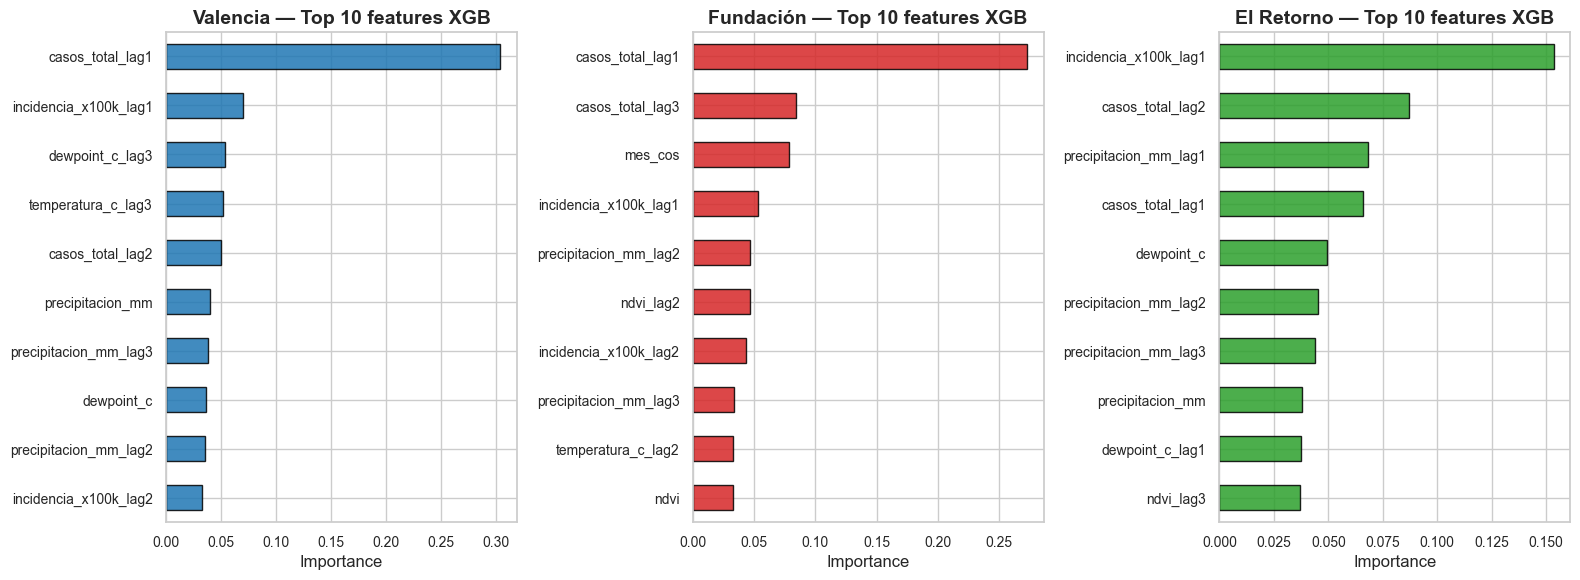

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)
for ax, (cod, nom) in zip(axes, MUNICIPIOS_FOCO.items()):
    modelo = modelos_xgb[cod]["model"]
    importances = pd.Series(modelo.feature_importances_, index=FEATURES)
    top = importances.sort_values(ascending=True).tail(10)
    top.plot(kind="barh", ax=ax, color=COLOR[cod], edgecolor="black", alpha=0.85)
    ax.set_title(f"{nom} — Top 10 features XGB", fontweight="bold")
    ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(OUT_GRAPH / "07_feature_importance.png", dpi=120,
            bbox_inches="tight")
plt.show()


## 8. Guardar artefactos

- `models/{cod}_logistic.joblib` y `models/{cod}_xgboost.joblib` para cada foco.
- `data/processed/predicciones_test.csv` con predicciones del test
  consolidadas (lista para el dashboard).


In [11]:
# Guardar joblibs individuales (consistente con el formato del dashboard:
# dict con {model, scaler, features}).
for cod, nom in tqdm(MUNICIPIOS_FOCO.items(), desc="Guardando modelos"):
    joblib.dump(
        {k: modelos_log[cod][k] for k in ("model", "scaler", "features")},
        MODELS_DIR / f"{cod}_logistic.joblib"
    )
    bundle_xgb = {k: modelos_xgb[cod][k] for k in ("model", "scaler", "features")}
    bundle_xgb["best_params"] = modelos_xgb[cod]["best_params"]
    joblib.dump(bundle_xgb, MODELS_DIR / f"{cod}_xgboost.joblib")

# CSV de predicciones del test (todos los municipios, ambos modelos)
filas_pred = []
for cod, nom in MUNICIPIOS_FOCO.items():
    _, _, te = preparar_subset(cod)
    te = te.copy()
    te["municipio"] = nom
    te["pred_logistic"]  = modelos_log[cod]["y_pred"]
    te["proba_logistic"] = modelos_log[cod]["y_proba"]
    te["pred_xgboost"]   = modelos_xgb[cod]["y_pred"]
    te["proba_xgboost"]  = modelos_xgb[cod]["y_proba"]
    te["pred_baseline"]  = (te["casos_total_lag1"] > 2).astype(int)
    filas_pred.append(te[[
        "cod_mpio", "municipio", "ano", "mes", "casos_total", "exceso",
        "pred_baseline", "pred_logistic", "proba_logistic",
        "pred_xgboost", "proba_xgboost"
    ]])

predicciones = pd.concat(filas_pred, ignore_index=True)
predicciones.to_csv(OUT_PRED, index=False)
print(f"  → {OUT_PRED}")
print(f"  → {MODELS_DIR}/ (6 joblibs)")
predicciones.head()


Guardando modelos:   0%|          | 0/3 [00:00<?, ?it/s]

  → C:\Users\JHON EDWAR\Documents\MAESTRIA EN INTELIGENCIA ARTIFICIAL\Desarrollo de Soluciones\dengue-eda\data\processed\predicciones_test.csv
  → C:\Users\JHON EDWAR\Documents\MAESTRIA EN INTELIGENCIA ARTIFICIAL\Desarrollo de Soluciones\dengue-eda\models/ (6 joblibs)


,cod_mpio,municipio,ano,mes,casos_total,exceso,pred_baseline,pred_logistic,proba_logistic,pred_xgboost,proba_xgboost
0,23855,Valencia,2020,1,19,1,1,1,1.000000,1,0.984447
1,23855,Valencia,2020,2,21,1,1,1,0.999984,1,0.980825
2,23855,Valencia,2020,3,6,1,1,1,0.999963,1,0.975794
3,23855,Valencia,2020,4,1,0,1,1,0.868106,0,0.398572
4,23855,Valencia,2020,5,0,0,0,0,0.388752,0,0.306738


## 9. Conclusiones del modelado

> Esta celda se llena después de inspeccionar las tablas y gráficos arriba.
> Punto de partida para escribir el capítulo de resultados del informe.

### Comparador externo
- **Modelo nacional Entrega 1**: P = 0.43 / R = 0.87 — "alarmista", baja confianza.

### Comparativo interno (test 2020-2024)
- _[Llenar con los números reales una vez ejecutado el notebook.]_

### Por municipio
- **Valencia**: _[mejor modelo, P/R, observaciones]_
- **Fundación**: _[idem]_
- **El Retorno**: _[idem]_

### Features más importantes
- _[Por municipio según XGBoost — anotar las top 3]_

### ¿Cumplimos el objetivo cuantitativo del proyecto?
Objetivo definido en `docs/mejoras_proyecto_post_reunion_carlos.md`:
> *Precision > 43% en al menos la mitad de los foco, manteniendo Recall > 60%.*

_[Sí/No — justificar con la tabla.]_

### Próximos pasos
1. Empaquetar artefactos para el dashboard (Paso 6).
2. Adaptar `dashboard_dengue/app.py` a la estructura per-municipio.
